# AI-Based Customer Churn Prediction System 

## Problem Statement
Customer churn is a major challenge in the telecom industry, where losing existing customers directly impacts revenue and growth.  
The objective of this project is to **predict whether a customer is likely to churn** using data mining principles and machine learning models.

## Project Objectives
- Perform **Exploratory Data Analysis (EDA)**
- Apply **data preprocessing and feature engineering**
- Train multiple **Machine Learning models**
- Benchmark model performance using multiple evaluation metrics
- Derive **business insights for data-driven decision-making**

## Application Domain
**Telecommunications / Customer Relationship Management (CRM)**

## Dataset
**Telco Customer Churn Dataset**


## Methodology Workflow
1. Data Loading
2. Data Cleaning & Preprocessing
3. Encoding
4. Features & Target
5. SMOTE (Class Balancing)
6. Train-Test Split
7. Feature Scaling
8. Handling Missing Values   
9. Feature Engineering
10. Exploratory Data Analsis (EDA)
11. Defining Models  
12. Model Training & Benchmarking 
13. Final Model Evaluation  
14. Insights & Conclusion


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import precision_score, recall_score, f1_score

## Loading Dataset

In [2]:
data = pd.read_csv("Telco-Customer-Churn.csv")

data_original = pd.read_csv("Telco-Customer-Churn.csv")
data = data_original.copy()

print("First 5 rows:\n", data.head())
print("\nDataset Info:\n")
print(data.info())

First 5 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

## Data Cleaning

In [3]:
data = data.drop('customerID', axis=1)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

## Encoding

In [4]:
data = pd.get_dummies(data, drop_first=True)

## Features & Target

In [5]:
X = data.drop('Churn_Yes', axis=1)
y = data['Churn_Yes']

## SMOTE (Class Balancing)

In [6]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:", np.bincount(y_resampled))


After SMOTE: [5174 5174]


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

## Feature Scaling

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Missing Values

In [9]:
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

## Feature Engineering

In [10]:
data['AvgCharges'] = data['TotalCharges'] / (data['tenure'] + 1)

## Exploratory Data Analysis (EDA)

In [11]:
print("\nStatistical Summary:\n", data.describe())
print("\nClass Distribution:\n", data['Churn_Yes'].value_counts())
print("\nMissing Values:\n", data.isnull().sum())


Statistical Summary:
        SeniorCitizen       tenure  MonthlyCharges  TotalCharges   AvgCharges
count    7043.000000  7043.000000     7043.000000   7043.000000  7043.000000
mean        0.162147    32.371149       64.761692   2281.916928    61.173413
std         0.368612    24.559481       30.090047   2265.270398    61.019723
min         0.000000     0.000000       18.250000     18.800000     9.183333
25%         0.000000     9.000000       35.500000    402.225000    26.274411
50%         0.000000    29.000000       70.350000   1397.475000    61.150000
75%         0.000000    55.000000       89.850000   3786.600000    84.940047
max         1.000000    72.000000      118.750000   8684.800000  1397.475000

Class Distribution:
 Churn_Yes
False    5174
True     1869
Name: count, dtype: int64

Missing Values:
 SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_M

### Visual Insights
These visualizations help derive meaningful insights from the dataset and support managerial decision-making.

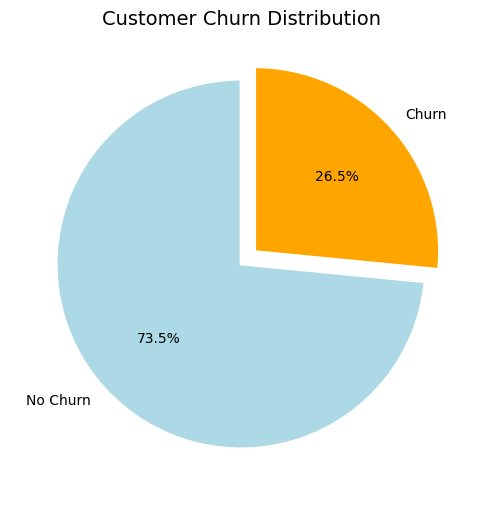

In [12]:
churn_counts = data['Churn_Yes'].value_counts()
colors = ['lightblue', 'orange']  

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.1),  
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} 
)

plt.title("Customer Churn Distribution", fontsize=14)
plt.show()

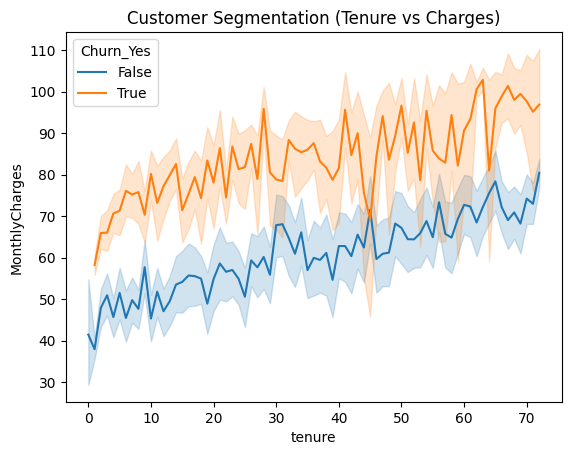

In [13]:
plt.figure()
sns.lineplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn_Yes',
    data=data
)
plt.title("Customer Segmentation (Tenure vs Charges)")
plt.show()

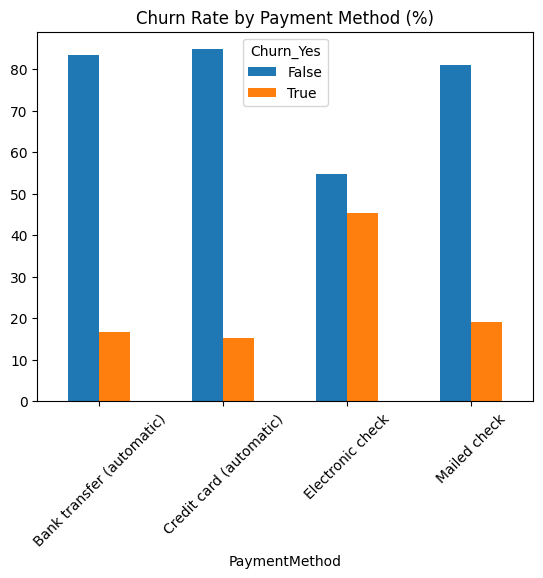

In [14]:
payment_churn = pd.crosstab(
    data_original['PaymentMethod'],
    data['Churn_Yes'],
    normalize='index'
) * 100

payment_churn.plot(kind='bar')
plt.title("Churn Rate by Payment Method (%)")
plt.xticks(rotation=45)
plt.show()

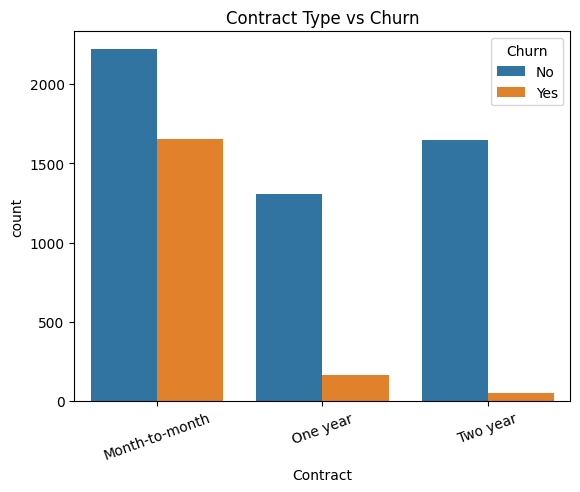

In [15]:
plt.figure()
sns.countplot(x='Contract', hue='Churn', data=data_original)
plt.xticks(rotation=20)
plt.title("Contract Type vs Churn")
plt.show()

## Defining Models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

## Model Training & Benchmarking
The following section trains & compares the performance of all selected models using:
- Accuracy
- Precision
- Recall
- F1 Score

These metrics help justify the model selection rationale.


In [17]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)

print("\nModel Comparison Table:\n")
print(results_df)


Model Comparison Table:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.844928   0.846667  0.847474  0.847070
1        Decision Tree  0.798068   0.793488  0.813155  0.803202
2        Random Forest  0.855072   0.857689  0.856053  0.856870


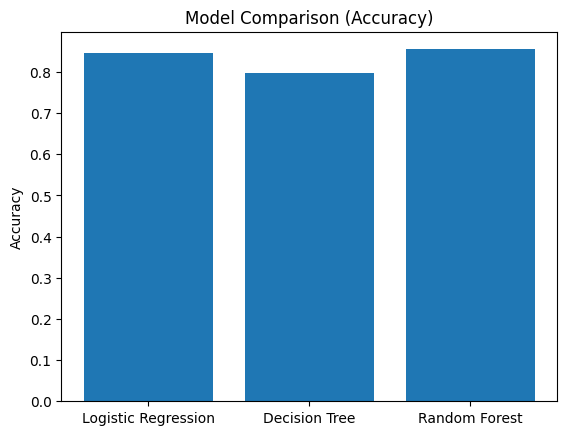

In [18]:
plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

## Final Model Evaluation
The best-performing model is selected based on **F1 Score**, since churn prediction is a classification problem where class imbalance matters.


In [19]:
best_model_name = results_df.loc[
    results_df['F1 Score'].idxmax(), 'Model'
]

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]


Best Model: Random Forest


In [20]:
y_pred = best_model.predict(X_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[872 149]
 [151 898]]

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.85      0.85      1021
        True       0.86      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



### Feature Importance


Top 10 Important Features:
                            Feature  Importance
3                     TotalCharges    0.167093
1                           tenure    0.153031
2                   MonthlyCharges    0.133947
28  PaymentMethod_Electronic check    0.105960
10     InternetService_Fiber optic    0.050280
25               Contract_Two year    0.041574
26            PaperlessBilling_Yes    0.040133
9                MultipleLines_Yes    0.023547
4                      gender_Male    0.023251
21                 StreamingTV_Yes    0.019814


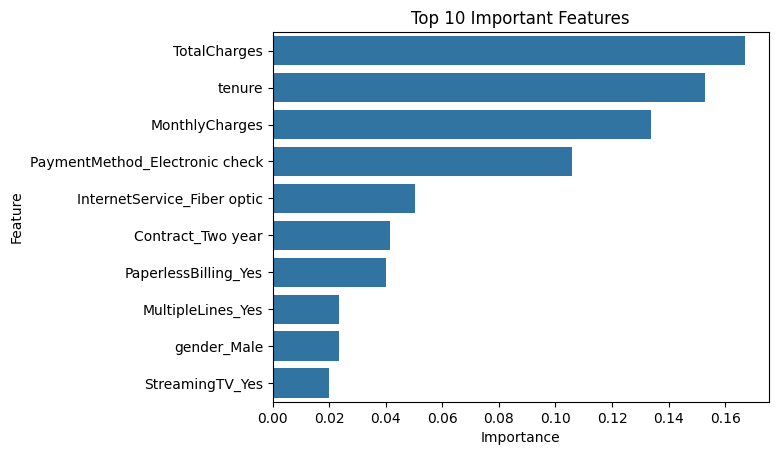

In [21]:
if best_model_name == "Random Forest":
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\nTop 10 Important Features:\n", importance.head(10))

    plt.figure()
    sns.barplot(x='Importance', y='Feature', data=importance.head(10))
    plt.title("Top 10 Important Features")
    plt.show()

## Conclusion
This project successfully demonstrates an **end-to-end AI-based data mining system** for customer churn prediction.

### Key Findings
- Customer churn can be effectively predicted using machine learning
- Class imbalance was addressed using **SMOTE**
- Multiple models were benchmarked for fair comparison
- The selected best model supports **business retention strategies**

### Business Value
The system helps telecom companies:
- identify high-risk customers
- reduce churn rate
- improve customer retention campaigns
- make data-driven strategic decisions

### Future Improvements
- Hyperparameter tuning
- XGBoost / LightGBM benchmarking
- deployment using Streamlit / Flask
- real-time prediction dashboard
